In [2]:
from srnet.data.components.sr_dataset import SRDataset
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

dataset = SRDataset(
    base_dataset=datasets.Imagenette(root="../data", split="train"),
    scale=4,
    hr_crop_size=256,
    interpolation="bicubic",
    training=False,
)
lr_original, hr = dataset[0]

In [3]:
print(lr_original.shape, hr.shape)

torch.Size([3, 64, 64]) torch.Size([3, 256, 256])


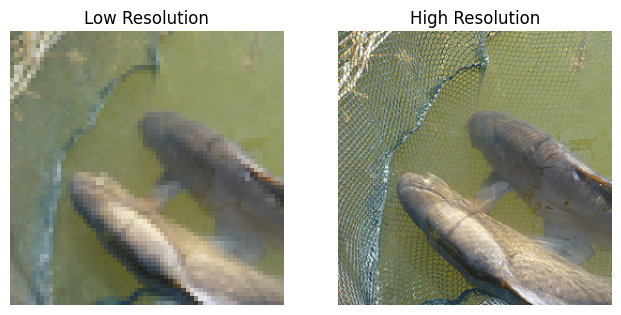

In [4]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Low Resolution")
plt.imshow(lr_original.permute(1, 2, 0).cpu().numpy())
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("High Resolution")
plt.imshow(hr.permute(1, 2, 0).cpu().numpy())
plt.axis("off")

plt.show()

In [9]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

lr_up = F.interpolate(
    lr_original.unsqueeze(0),
    size=hr.shape[-2:],   # 🔴 important
    mode="bicubic",
    align_corners=False,
    antialias=False,
).squeeze(0)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

lr = F.interpolate(
    hr.unsqueeze(0),
    size=lr_original.shape[-2:],
    mode="bicubic",
    align_corners=False,
    antialias=True,
).squeeze(0)

diff = (lr - lr).abs().mean()
print("Mean abs diff:", diff.item())

lr_up = F.interpolate(
    lr.unsqueeze(0),
    size=hr.shape[-2:],   # 🔴 important
    mode="bicubic",
    align_corners=False,
    antialias=True,
).squeeze(0)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

Mean abs diff: 0.04680512472987175
Mean abs diff: 0.0
Mean abs diff: 0.046922165900468826


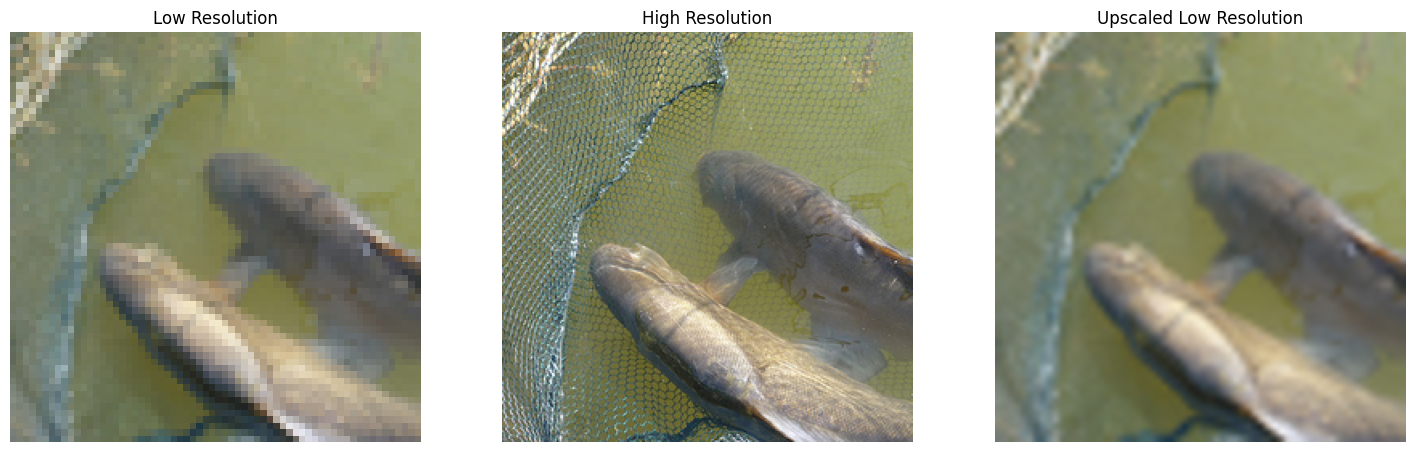

In [10]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title("Low Resolution")
plt.imshow(lr.permute(1, 2, 0).cpu().numpy())
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("High Resolution")
plt.imshow(hr.permute(1, 2, 0).cpu().numpy())
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Upscaled Low Resolution")
plt.imshow(lr_up.permute(1, 2, 0).cpu().numpy())
plt.axis("off")

plt.show()      

In [11]:
print("Data range of HR:", hr.min().item(), hr.max().item())
print("Data range of LR:", lr.min().item(), lr.max().item())
print("Data range of LR upscaled:", lr_up.min().item(), lr_up.max().item())

Data range of HR: 0.007843137718737125 1.0
Data range of LR: 0.11099687963724136 0.9521650075912476
Data range of LR upscaled: 0.10901894420385361 0.966422975063324


In [16]:
import torch


def bicubic_resize(x, scale):
    return torch.clamp(
        torch.nn.functional.interpolate(
            x.unsqueeze(0), scale_factor=scale, mode="bicubic", align_corners=False, antialias=True
        ),
        0.0,
        1.0,
    ).squeeze(0)

In [23]:
import torch
from torchvision.transforms import v2


def bicubic_resize_v2(x, scale):
    return torch.clamp(
        v2.Resize(
            size=(int(x.shape[1] * scale), int(x.shape[2] * scale)), interpolation=3
        )(x),
        0.0,
        1.0,
    ).squeeze(0)

In [24]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

lr_up = bicubic_resize(lr_original, scale=4)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

lr = bicubic_resize(hr, scale=0.25)

diff = (lr - lr).abs().mean()
print("Mean abs diff:", diff.item())

lr_up = bicubic_resize(lr, scale=4)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

Mean abs diff: 0.046922165900468826
Mean abs diff: 0.0
Mean abs diff: 0.046922165900468826


In [25]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

lr_up = bicubic_resize_v2(lr_original, scale=4)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

lr = bicubic_resize_v2(hr, scale=0.25)

diff = (lr - lr).abs().mean()
print("Mean abs diff:", diff.item())

lr_up = bicubic_resize_v2(lr, scale=4)

diff = (lr_up - hr).abs().mean()
print("Mean abs diff:", diff.item())

Mean abs diff: 0.046922165900468826
Mean abs diff: 0.0
Mean abs diff: 0.046922165900468826
